In [1]:
import sys
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

sys.path.append(os.path.abspath('..'))

from src.config import TARGET_CLASSES, IMAGE_SIZE, BATCH_SIZE, GENERATE_COUNT_MAP
from src.utils.data_loader import ButterflyDataset
from src.utils.metrics import inception_score, frechet_inception_distance, mean_ssim

NUM_CLASSES = len(TARGET_CLASSES)   # número de classes condicionais
print(f"Classes: {TARGET_CLASSES}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

Classes: ['AMERICAN SNOOT', 'CRIMSON PATCH', 'MALACHITE', 'GOLD BANDED', 'WOOD SATYR']
NUM_CLASSES: 5


In [2]:
path    = "splits"
img_dir = '../data/raw/train'
df      = pd.read_csv(os.path.join(path, 'full_train_split.csv'))

data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),          # augmentação leve — ajuda o G
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],       # [0,1] → [-1, 1]  (alinha com Tanh)
                         [0.5, 0.5, 0.5]),
])

dataset    = ButterflyDataset(df=df, img_dir=img_dir,
                               transform=data_transform,
                               target_classes=None)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Dataset: {len(dataset)} imagens | {len(dataloader)} batches/época")


Dataset: 4159 imagens | 130 batches/época


In [3]:
full_train_df = pd.read_csv('splits/full_train_split.csv')
train_df = pd.read_csv('splits/train_split.csv')
val_df = pd.read_csv('splits/val_split.csv')
test_df = pd.read_csv('splits/test_split.csv')

train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

full_train_dataset = ButterflyDataset(df=full_train_df, img_dir=img_dir, transform=data_transform)
full_train_dataloader = data.DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()       else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print("Device:", device)

Device: cuda


# 1. Conditional AE

In [5]:
from src.ae.conditional_vae_1 import ConditionalVAE
from src.ae.conditional_vae_train import cvae_loss_function, train_cvae
from src.ae.conditional_vae_images import plot_cvae_losses, comparar_duas_classes, comparar_reais_vs_sinteticas
from src.ae.conditional_evaluate import evaluate
from src.ae.conditional_vae_save import save_cvae_experiment


In [6]:
cvae_model = ConditionalVAE(img_channels=3, num_classes=75, latent_dim=128, img_size=IMAGE_SIZE)
cvae_model, cvae_history = train_cvae(
    model=cvae_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,
    epochs=100,
    stop=5,
    loss_function='bce'
)

hiperparametros_cvae = {
    "model_architecture": "ConditionalVAE_1",
    "epochs": 100,
    "stop": 5,
    "latent_dim": 128,
    "loss_function": "bce"
}

/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [252,0,0], thread: [16,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [252,0,0], thread: [103,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [252,0,0], thread: [107,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [252,0,0], thread: [115,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [252,0,0], thread: [125,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [14,0,0], thread: [32,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [14,0,0], thread: [

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


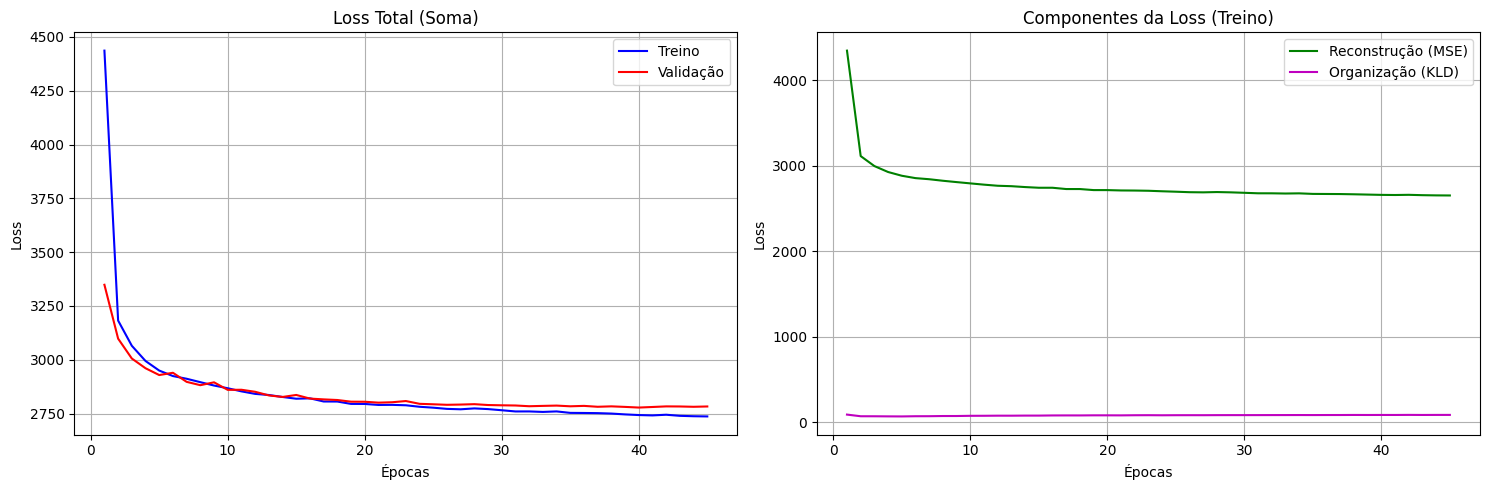

In [20]:
plot_cvae_losses(cvae_history, save=False)

In [ ]:
resultados_metricas = evaluate(
    model=cvae_model,
    dataloader=val_dataloader, 
    device=device,
    num_imagens=2048
)

In [ ]:
run_dir = save_cvae_experiment(
    model=cvae_model,
    history=cvae_history,
    config=hiperparametros_cvae,
    metrics=resultados_metricas,
    base_dir="../src/ae/experiments"
)

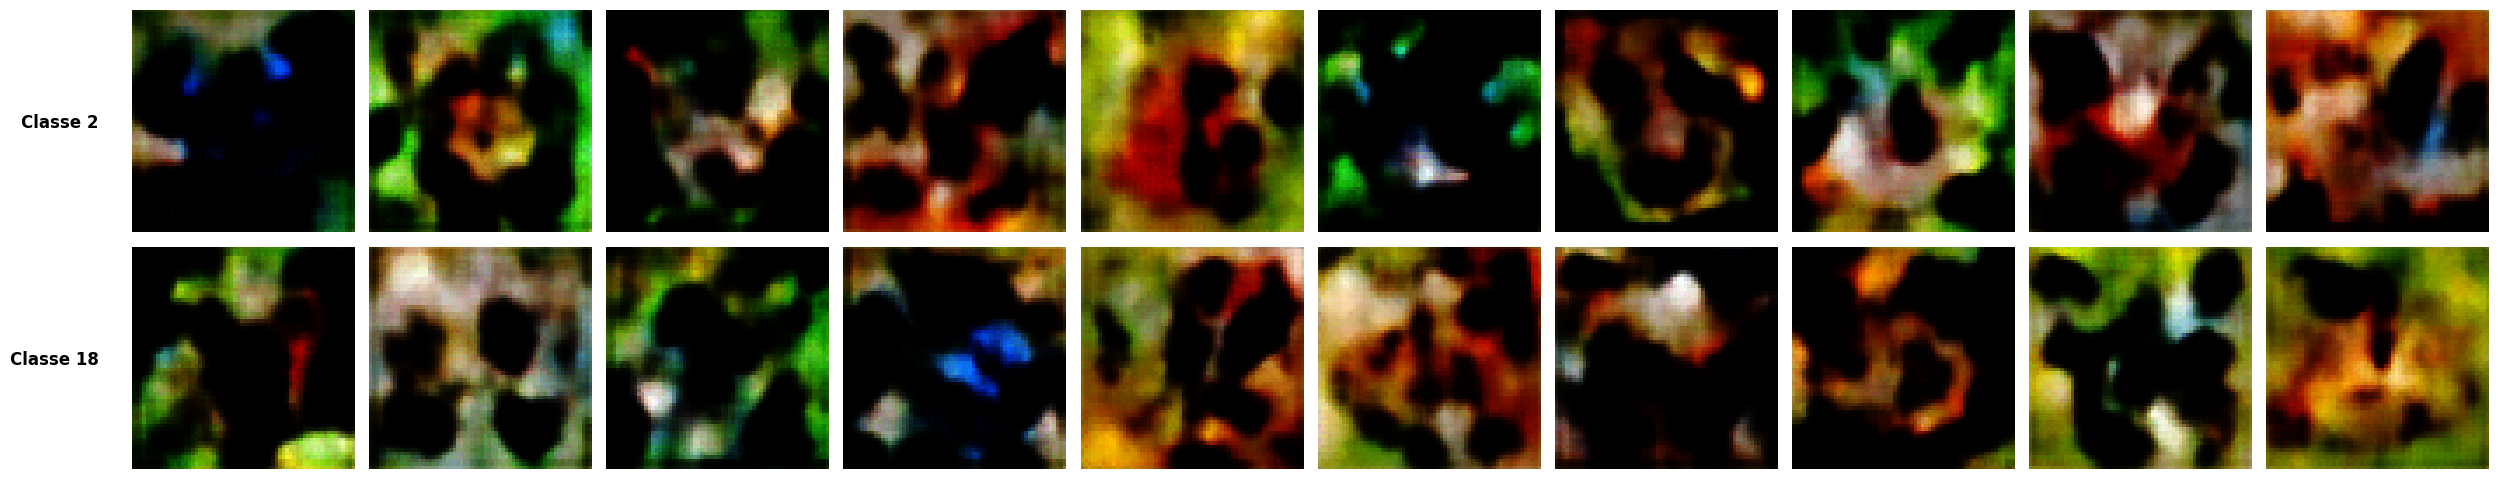

In [21]:
comparar_duas_classes(
    model=cvae_model, 
    device=device, 
    classe_A=2, 
    classe_B=18, 
    num_samples=10,
    save=run_dir
)

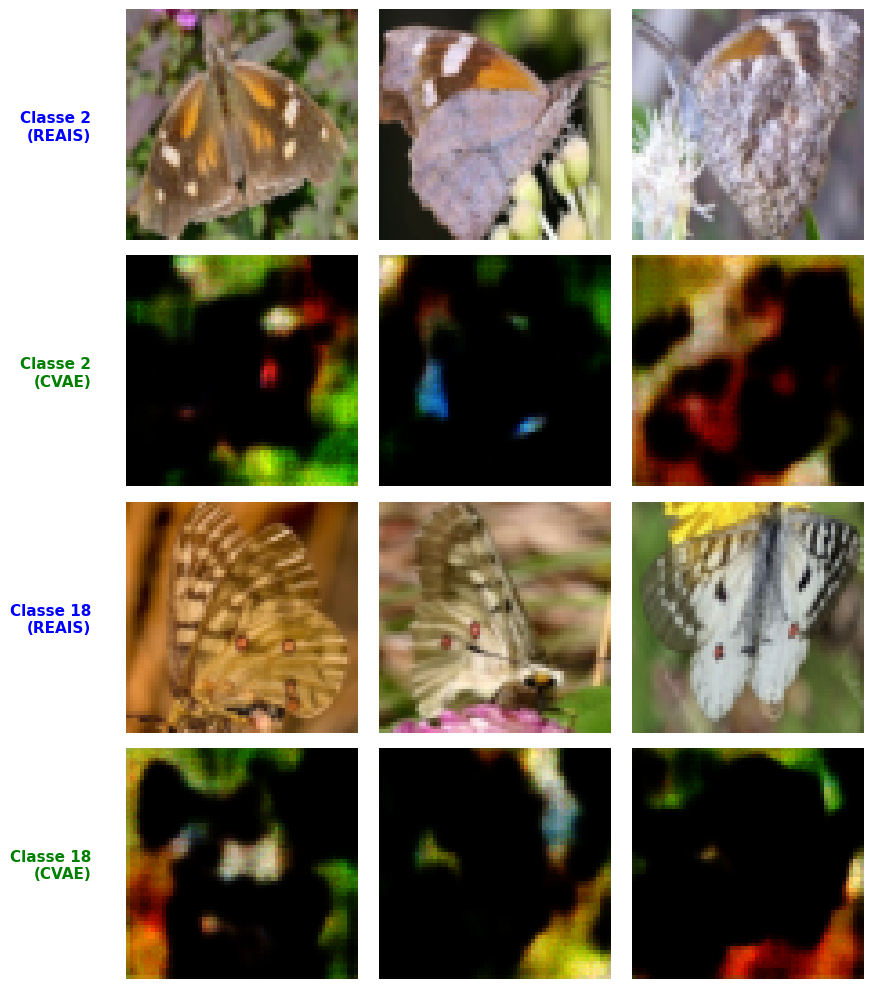

In [22]:
comparar_reais_vs_sinteticas(
    model=cvae_model,
    device=device,
    dataloader=train_dataloader,
    classe_A=2,
    classe_B=18,
    num_samples=5,
    save=run_dir
)